In [1]:
from pathlib import Path

RAW = Path("../data/raw")

print("Files in data/raw/:")
for f in RAW.iterdir():
    print(f"  {f.name}  ({f.stat().st_size / 1024:.0f} KB)")
    

Files in data/raw/:
  inkar_2025.zip  (423624 KB)
  vg250_01-01.utm32s.shape.ebenen.zip  (67517 KB)


In [2]:
import zipfile

bkg_zip = RAW / "vg250_01-01.utm32s.shape.ebenen.zip"

with zipfile.ZipFile(bkg_zip, "r") as z:
    shp_files = [name for name in z.namelist() if name.lower().endswith(".shp")]
    
print("Shapefiles inside BKG ZIP:")
for name in shp_files:
    print(name)
    

Shapefiles inside BKG ZIP:
vg250_01-01.utm32s.shape.ebenen/vg250_ebenen_0101/VG250_GEM.shp
vg250_01-01.utm32s.shape.ebenen/vg250_ebenen_0101/VG250_KRS.shp
vg250_01-01.utm32s.shape.ebenen/vg250_ebenen_0101/VG250_LAN.shp
vg250_01-01.utm32s.shape.ebenen/vg250_ebenen_0101/VG250_LI.shp
vg250_01-01.utm32s.shape.ebenen/vg250_ebenen_0101/VG250_PK.shp
vg250_01-01.utm32s.shape.ebenen/vg250_ebenen_0101/VG250_RBZ.shp
vg250_01-01.utm32s.shape.ebenen/vg250_ebenen_0101/VG250_STA.shp
vg250_01-01.utm32s.shape.ebenen/vg250_ebenen_0101/VG250_VWG.shp


In [3]:
from pathlib import Path

print("Shapefiles inside BKG ZIP:")
for name in shp_files:
    print(Path(name).name)
    

Shapefiles inside BKG ZIP:
VG250_GEM.shp
VG250_KRS.shp
VG250_LAN.shp
VG250_LI.shp
VG250_PK.shp
VG250_RBZ.shp
VG250_STA.shp
VG250_VWG.shp


In [4]:
import geopandas as gpd

gem_path = (
    "zip://"
    + str(bkg_zip)
    + "!vg250_01-01.utm32s.shape.ebenen/vg250_ebenen_0101/VG250_GEM.shp"
)

gem = gpd.read_file(gem_path)

print("Shape:", gem.shape)
print("CRS:", gem.crs)
print("Columns:")
print(list(gem.columns))

gem.head(3)

Shape: (11103, 27)
CRS: EPSG:25832
Columns:
['OBJID', 'BEGINN', 'ADE', 'GF', 'BSG', 'LKZ', 'ARS', 'AGS', 'SDV_ARS', 'GEN', 'BEZ', 'IBZ', 'BEM', 'NBD', 'SN_L', 'SN_R', 'SN_K', 'SN_V1', 'SN_V2', 'SN_G', 'FK_S3', 'NUTS', 'ARS_0', 'AGS_0', 'WSK', 'DLM_ID', 'geometry']


,OBJID,BEGINN,ADE,GF,BSG,LKZ,ARS,AGS,SDV_ARS,GEN,...,SN_V1,SN_V2,SN_G,FK_S3,NUTS,ARS_0,AGS_0,WSK,DLM_ID,geometry
0,DEBKGVG200000008,2022-12-20,6,4,1,SH,010010000000,01001000,010010000000,Flensburg,...,00,00,000,R,DEF01,010010000000,01001000,2008-01-01,DEBKGDL20000E5MA,"POLYGON ((527173.204 6075202.115, 527199.066 6..."
1,DEBKGVG200000009,2025-01-04,6,4,1,SH,010020000000,01002000,010020000000,Kiel,...,00,00,000,R,DEF02,010020000000,01002000,2006-01-01,DEBKGDL20000004J,"POLYGON ((575797.258 6032310.691, 575841.569 6..."
2,DEBKGVG20000000A,2025-01-04,6,4,1,SH,010030000000,01003000,010030000000,Lübeck,...,00,00,000,R,DEF03,010030000000,01003000,2006-02-01,DEBKGDL20000DYMA,"POLYGON ((623482.947 5981779.206, 623460.091 5..."


NRW Gemeinden: 396
           AGS              GEN SN_L
2073  05111000       Düsseldorf   05
2074  05112000         Duisburg   05
2075  05113000            Essen   05
2076  05114000          Krefeld   05
2077  05116000  Mönchengladbach   05


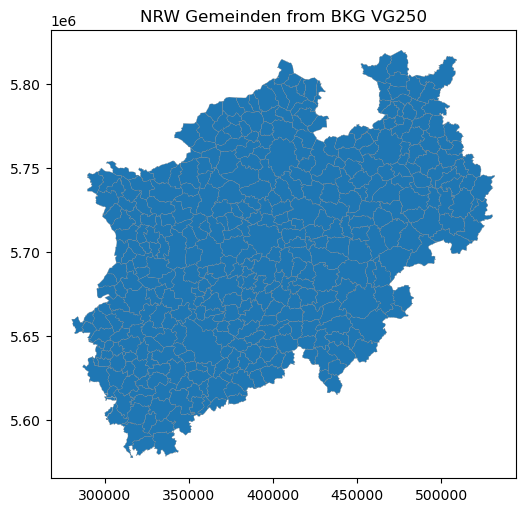

In [6]:
import matplotlib.pyplot as plt

gem_nrw = gem[gem["SN_L"] == "05"]

print("NRW Gemeinden:", len(gem_nrw))
print(gem_nrw[["AGS", "GEN", "SN_L"]].head())

gem_nrw.plot(figsize=(6, 6), edgecolor="grey", linewidth=0.2)
plt.title("NRW Gemeinden from BKG VG250")
plt.show()

In [7]:
inkar_zip = RAW / "inkar_2025.zip"

with zipfile.ZipFile(inkar_zip, "r") as z:
    files = z.namelist()

print("Files inside INKAR ZIP:")
for name in files[:50]:
    print(name)

print("\nTotal files:", len(files))


Files inside INKAR ZIP:
BBSR_Raumgliederungen_Referenz_2023.xlsx
Indikatorenübersicht (INKAR 2025).xlsx
inkar_2025.csv
Readme.txt

Total files: 4


In [9]:
import pandas as pd
import zipfile

with zipfile.ZipFile(inkar_zip, "r") as z:
    with z.open("inkar_2025.csv") as f:
        inkar = pd.read_csv(
            f,
            sep=";",
            decimal=",",
            encoding="utf-8",
            low_memory=False
        )

print("Shape:", inkar.shape)
print("Columns:")
print(list(inkar.columns))

inkar.head(3)



NotImplementedError: That compression method is not supported

In [ ]:
import pandas as pd

inkar_csv = RAW / "inkar_2025" / "inkar_2025.csv"

inkar = pd.read_csv(
    inkar_csv,
    sep=";",
    decimal=",",
    encoding="utf-8",
    low_memory=False
)

print("Shape:", inkar.shape)
print("Columns:")
print(list(inkar.columns))

inkar.head(3)


In [1]:
import pandas as pd

inkar_csv = RAW / "inkar_2025" / "inkar_2025.csv"

inkar_sample = pd.read_csv(
    inkar_csv,
    sep=";",
    decimal=",",
    encoding="utf-8",
    nrows=10
)

print("Sample shape:", inkar_sample.shape)
print("Columns:")
print(list(inkar_sample.columns))

inkar_sample.head(10)

NameError: name 'RAW' is not defined

In [2]:
from pathlib import Path
import pandas as pd

RAW = Path("../data/raw")

inkar_csv = RAW / "inkar_2025" / "inkar_2025.csv"

inkar_sample = pd.read_csv(
    inkar_csv,
    sep=";",
    decimal=",",
    encoding="utf-8",
    nrows=10
)

print("Sample shape:", inkar_sample.shape)
print("Columns:")
print(list(inkar_sample.columns))

inkar_sample.head(10)

Sample shape: (10, 9)
Columns:
['Bereich', 'ID', 'Kuerzel', 'Indikator', 'Raumbezug', 'Kennziffer', 'Name', 'Zeitbezug', 'Wert']


,Bereich,ID,Kuerzel,Indikator,Raumbezug,Kennziffer,Name,Zeitbezug,Wert
0,EU,18668,q_alo,Arbeitslosenquote,EU27,EU27,Europäische Union - 27 Länder (ab 2020),2021,7.0
1,EU,18668,q_alo,Arbeitslosenquote,NUTS0,AT,Österreich,2021,6.2
2,EU,18668,q_alo,Arbeitslosenquote,NUTS0,BE,Belgien,2021,6.3
3,EU,18668,q_alo,Arbeitslosenquote,NUTS0,BG,Bulgarien,2021,5.3
4,EU,18668,q_alo,Arbeitslosenquote,NUTS0,CY,Zypern,2021,7.5
5,EU,18668,q_alo,Arbeitslosenquote,NUTS0,CZ,Tschechien,2021,2.8
6,EU,18668,q_alo,Arbeitslosenquote,NUTS0,DE,Deutschland,2021,3.6
7,EU,18668,q_alo,Arbeitslosenquote,NUTS0,DK,Dänemark,2021,5.0
8,EU,18668,q_alo,Arbeitslosenquote,NUTS0,EE,Estland,2021,6.2
9,EU,18668,q_alo,Arbeitslosenquote,NUTS0,EL,Griechenland,2021,14.7


In [3]:
raumbezug_values = set()

for chunk in pd.read_csv(
    inkar_csv,
    sep=";",
    decimal=",",
    encoding="utf-8",
    usecols=["Raumbezug"],
    chunksize=500_000
):
    raumbezug_values.update(chunk["Raumbezug"].dropna().unique())

print("Unique Raumbezug values:")
for value in sorted(raumbezug_values):
    print(value)
    

Unique Raumbezug values:
Arbeitsmarktregionen
BBSR-Mittelbereiche
Braunkohlereviere (auch nicht förderfähige)
Bund
Bundesländer
EU27
Gemeinden
Gemeindeverbände (Verwaltungsgemeinschaft)
Großstadtregionaler Einzugsbereich
Großstadtregionen
IHK-Bezirke
Kreise
Kreisregionen
Metropolregionen
NUTS0
NUTS1
NUTS2
Raumordnungsregionen
Raumtyp Bezug: Lage (Gemeindeverbände)
Raumtyp Bezug: Lage (Kreise)
Regierungsbezirke
Regionalstatistischer Raumtyp 17 (RegioStaR17)
Regionalstatistischer Raumtyp 2 (RegioStaR2)
Regionalstatistischer Raumtyp 7 (RegioStaR7)
Regionalstatistischer Raumtyp Gemeindetyp 5 (Regio
Siedlungsstruktureller Kreistyp
Siedlungsstruktureller Kreistyp (Bundesländer)
Siedlungsstruktureller Kreistyp (West-Ost)
Siedlungsstruktureller Regionstyp
Siedlungsstruktureller Regionstyp (Bundesländer)
Siedlungsstruktureller Regionstyp (West-Ost)
Stadt- und Gemeindetyp
Stadt- und Gemeindetyp (Bundesländer)
Stadt- und Gemeindetyp (West-Ost)
Stadt- und Gemeindetyp differenziert
Städtischer-Länd

In [4]:
gemeinden_sample = []

for chunk in pd.read_csv(
    inkar_csv,
    sep=";",
    decimal=",",
    encoding="utf-8",
    chunksize=500_000
):
    part = chunk[chunk["Raumbezug"] == "Gemeinden"]
    if not part.empty:
        gemeinden_sample.append(part.head(10))
        break

gemeinden_sample = pd.concat(gemeinden_sample)

print("Sample Gemeinden rows:")
print(gemeinden_sample[["Indikator", "Raumbezug", "Kennziffer", "Name", "Zeitbezug", "Wert"]])

gemeinden_sample.head(10)

Sample Gemeinden rows:
               Indikator  Raumbezug Kennziffer                    Name  \
30321        Bevölkerung  Gemeinden   01001000        Flensburg, Stadt   
30322            Bildung  Gemeinden   01001000        Flensburg, Stadt   
30323         Gesundheit  Gemeinden   01001000        Flensburg, Stadt   
30324  Siedlungsstruktur  Gemeinden   01001000        Flensburg, Stadt   
30325            Verkehr  Gemeinden   01001000        Flensburg, Stadt   
30326         Wirtschaft  Gemeinden   01001000        Flensburg, Stadt   
30327        Bevölkerung  Gemeinden   01002000  Kiel, Landeshauptstadt   
30328            Bildung  Gemeinden   01002000  Kiel, Landeshauptstadt   
30329         Gesundheit  Gemeinden   01002000  Kiel, Landeshauptstadt   
30330  Siedlungsstruktur  Gemeinden   01002000  Kiel, Landeshauptstadt   

       Zeitbezug   Wert  
30321       2023  100.0  
30322       2023  100.0  
30323       2023  100.0  
30324       2023  100.0  
30325       2023  100.0  
30326 

C:\Users\sophi\AppData\Local\Temp\ipykernel_22468\3140475529.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(


,Bereich,ID,Kuerzel,Indikator,Raumbezug,Kennziffer,Name,Zeitbezug,Wert
30321,EU,NaN,a_bb_4G,Bevölkerung,Gemeinden,01001000,"Flensburg, Stadt",2023,100.0
30322,EU,NaN,a_bb_4G,Bildung,Gemeinden,01001000,"Flensburg, Stadt",2023,100.0
30323,EU,NaN,a_bb_4G,Gesundheit,Gemeinden,01001000,"Flensburg, Stadt",2023,100.0
30324,EU,NaN,a_bb_4G,Siedlungsstruktur,Gemeinden,01001000,"Flensburg, Stadt",2023,100.0
30325,EU,NaN,a_bb_4G,Verkehr,Gemeinden,01001000,"Flensburg, Stadt",2023,100.0
30326,EU,NaN,a_bb_4G,Wirtschaft,Gemeinden,01001000,"Flensburg, Stadt",2023,100.0
30327,EU,NaN,a_bb_4G,Bevölkerung,Gemeinden,01002000,"Kiel, Landeshauptstadt",2023,100.0
30328,EU,NaN,a_bb_4G,Bildung,Gemeinden,01002000,"Kiel, Landeshauptstadt",2023,100.0
30329,EU,NaN,a_bb_4G,Gesundheit,Gemeinden,01002000,"Kiel, Landeshauptstadt",2023,100.0
30330,EU,NaN,a_bb_4G,Siedlungsstruktur,Gemeinden,01002000,"Kiel, Landeshauptstadt",2023,100.0
